# OSM roads 

This notebook downloads the roads (highway) from OpenStreetMap (OSM), filters the categories of interest, sort them by priority and then applies to each noise segment the first category which is within 5 m distance. 
It adds to the dataframe also the distance between the segment and the road, and the length of the segment.
Finally, it saves all the data into a csv.

In [1]:
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

## Import and analyse noise dataset

In [2]:
noise_streets = gpd.read_file("../../layers/BCN_noise_streets.gpkg")
print(noise_streets.crs)  #CRS = Coordinate Reference System
print(noise_streets.shape)
print(noise_streets.columns.tolist())
print("Number of street segments:", len(noise_streets))

EPSG:25831
(15115, 30)
['TRAM', 'TOTAL_D', 'TOTAL_E', 'TOTAL_N', 'TOTAL_DEN', 'TRANSIT_D', 'TRANSIT_E', 'TRANSIT_N', 'TRANSIT_DEN', 'GI_TR_D', 'GI_TR_E', 'GI_TR_N', 'GI_TR_DEN', 'FFCC_D', 'FFCC_E', 'FFCC_N', 'FFCC_DEN', 'INDUST_D', 'INDUST_E', 'INDUST_N', 'INDUST_DEN', 'VIANANTS_D', 'VIANANTS_E', 'OCI_N', 'PATIS_D', 'PATIS_E', 'geometry_type', 'start', 'end', 'geometry']
Number of street segments: 15115


## Roads - OSM

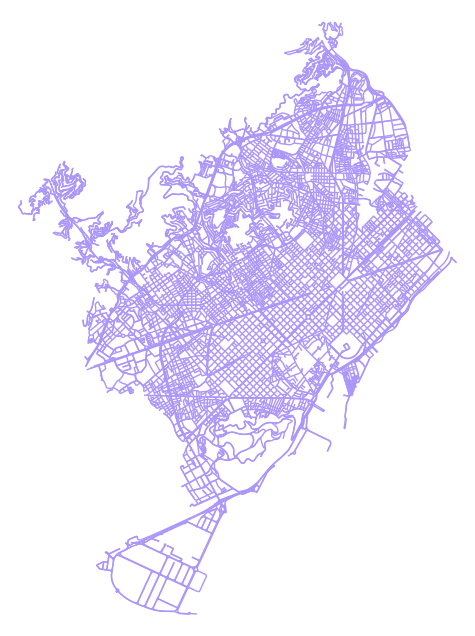

In [3]:
import osmnx as ox
#G = ox.graph_from_place("Barcelona, Spain", network_type="drive")
G = ox.load_graphml("data/barcelona.graphml")
ox.plot_graph(G, edge_color="#ab96f9ff", bgcolor="white", node_size=0)
ox.save_graphml(G, "barcelona.graphml")


## Prepare graph edges (roads)

In [4]:
nodes, edges = ox.graph_to_gdfs(G)

# Assign a unique segment_id to each edge based on its start and end nodes and its key
edges["segment_id"] = edges.index.map(lambda x: f"{x[0]}_{x[1]}_{x[2]}")
edges['segment_id'].head(10)

# Project edges to the same CRS as noise_streets
roads = edges[edges.geometry.type == 'LineString'].to_crs(noise_streets.crs)
roads.to_file("bcn_osmnx_edges.gpkg", layer="edges", driver="GPKG")

## Check features completeness

In [5]:
print("Checking width..")
print(roads['width'].value_counts(dropna=False))
print("Checking maxspeed..")
print(roads['maxspeed'].value_counts(dropna=False))
print("Checking public_transport..")
print(roads['lanes'].value_counts(dropna=False))
print("Checking oneway..")
print(roads['oneway'].value_counts(dropna=False))

Checking width..
width
NaN                 14834
5                     207
6                     177
8                     154
9                     145
                    ...  
[7, 11]                 1
[6, 4.6]                1
[6, 15]                 1
9.6                     1
[3, 5, 4.8, 4.9]        1
Name: count, Length: 122, dtype: int64
Checking maxspeed..
maxspeed
30              9063
50              3892
20              1473
NaN              812
10               593
[20, 30]         316
80                98
[50, 30]          80
40                64
60                41
[10, 30]          29
[20, 10]          20
[50, 80]           8
[30, 40]           7
70                 5
[50, 40]           5
[50, 60]           4
[80, 60]           4
[50, 30, 40]       4
[20, 50]           3
[20, 10, 30]       3
[20, 50, 30]       3
4                  2
[70, 50]           2
[10, 15]           1
[50, 80, 60]       1
[20, 40]           1
[1, 30]            1
[70, 40]           1
[70, 80]      

## Check if road is tunnel

In [6]:
roads['is_tunnel'] = roads['tunnel'].fillna('no').eq('yes').astype(int)

## Filter roads categories

In [7]:
# Filter to only categories that are likely to have noise data and are not tunnels
categories = ['living_street','residential','primary','secondary','tertiary','trunk']
roads_filtered = roads[roads['highway'].isin(categories)&
    (roads['is_tunnel'] == 0)]
print(f"Original: {len(roads)}, Filtered: {len(roads_filtered)}")

Original: 16541, Filtered: 15046


## Plot road categories distribution

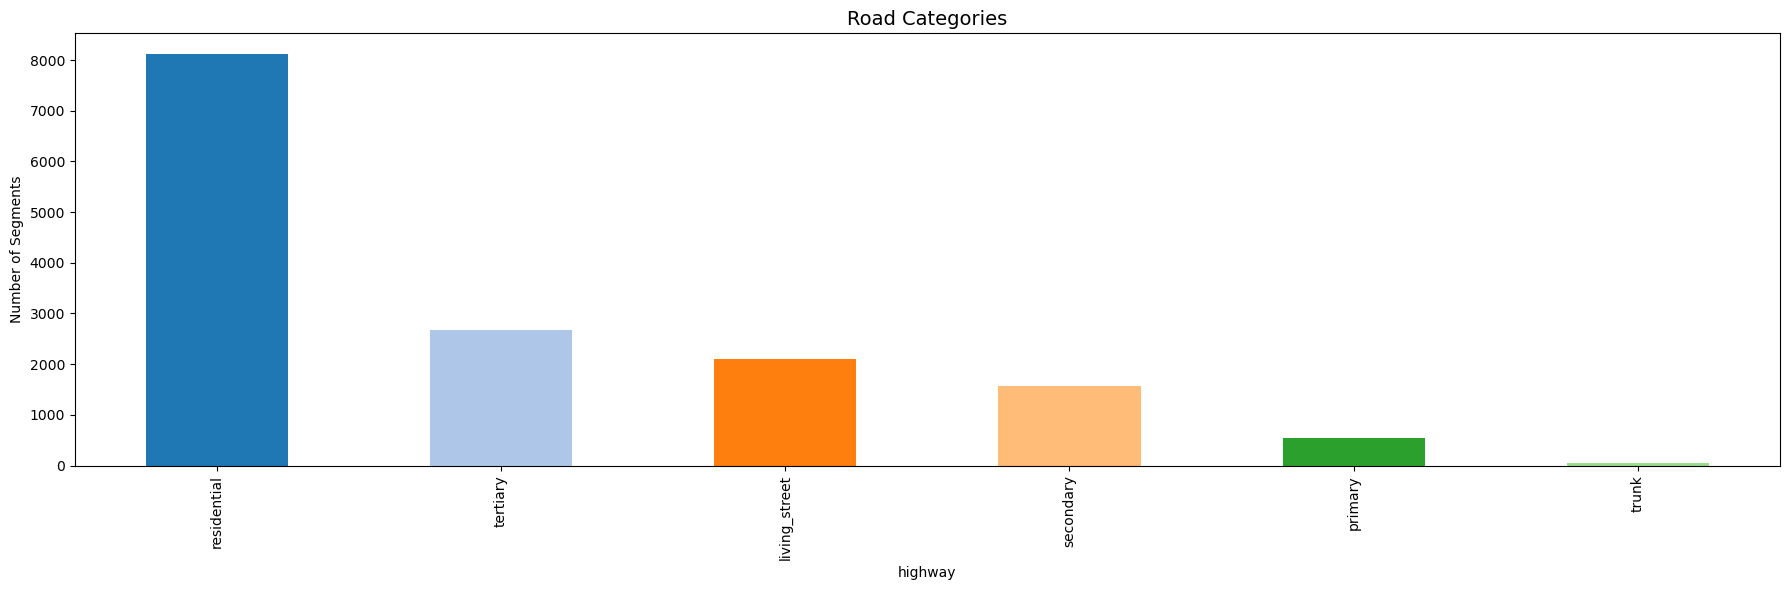

In [8]:
fig, axes = plt.subplots(1, 1, figsize=(18, 6))

class_count = roads_filtered['highway'].value_counts()

class_count.plot(kind='bar', ax=axes, color=plt.cm.tab20.colors[:len(class_count)])
axes.set_title("Road Categories", fontsize=14)
axes.set_ylabel("Number of Segments")
axes.tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


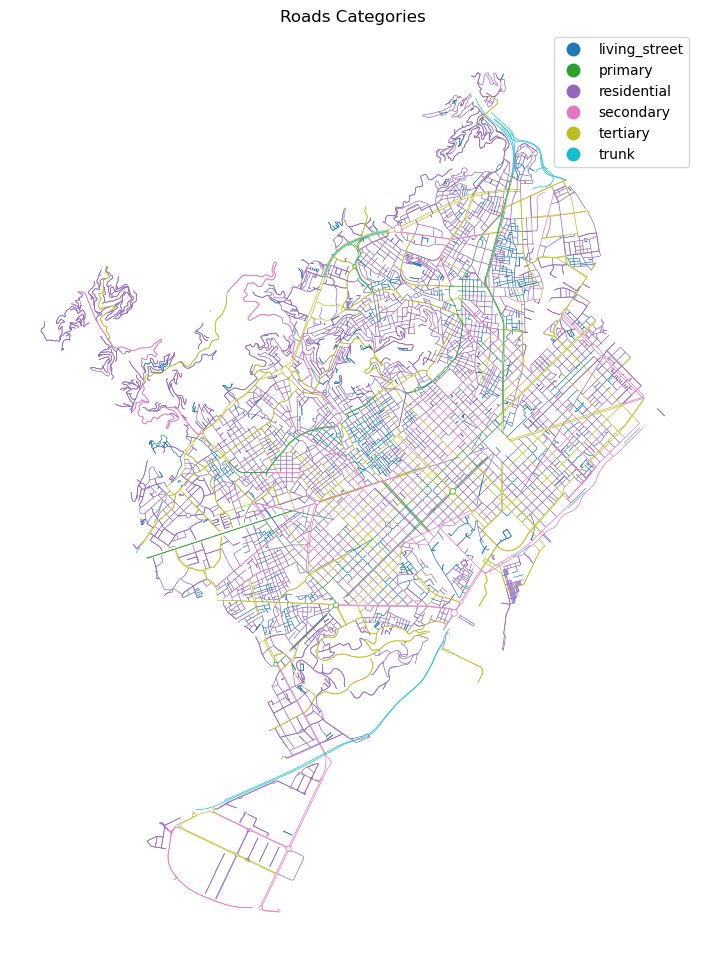

In [9]:
ax = roads_filtered.plot(column='highway', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Roads Categories')
ax.set_axis_off()

## Assign to each reoad segment the closest noise value

In [10]:
# Put a threshold on the distance to consider a match (e.g., 10 meters)
noise_roads = gpd.sjoin_nearest(roads_filtered, noise_streets, how='left',
                                 distance_col='distance', max_distance=10)
noise_roads = noise_roads.dropna(subset=['TOTAL_D'])  # remove unmatched roads
noise_roads = noise_roads.sort_values('distance').loc[~noise_roads.index.duplicated(keep='first')]
print(f"Before: {len(roads_filtered)}, Merged: {len(noise_roads)}")

Before: 15046, Merged: 14809


## Classify noise into 5 classes: <40, 40-50, 50-60, 60-70, >70

In [11]:
# Classify noise dB string into 5 classes: 0=<40, 1=40-50, 2=50-60, 3=60-70, 4=>70

def classify_noise(range_str):
    if range_str == '< 40 dB(A)':
        val = 35
    else:
        val = int((range_str).split(' - ')[0])
    if val < 40:
        return 0
    elif val < 50:
        return 1
    elif val < 60:
        return 2
    elif val < 70:
        return 3
    else:
        return 4

print(classify_noise('70 - 75 dB(A)'))  # expected: 4

4


In [12]:
noise_roads['noise_day'] = noise_roads['TOTAL_D'].apply(classify_noise)
noise_roads['noise_evening'] = noise_roads['TOTAL_E'].apply(classify_noise)
noise_roads['noise_night'] = noise_roads['TOTAL_N'].apply(classify_noise)

noise_roads.head()

osmid      highway lanes  \
u           v           key                                              
13859746870 13859746860 0                1518596100  residential     1   
13798851565 8465472214  0                 757887873  residential   NaN   
4538123419  13734642240 0                 959788822    secondary     3   
13845167536 847716886   0    [1449373108, 71213823]  residential   NaN   
                        0    [1449373108, 71213823]  residential   NaN   

                            maxspeed                    name  oneway reversed  \
u           v           key                                                     
13859746870 13859746860 0         30                     NaN    True    False   
13798851565 8465472214  0        NaN    Carrer de les Agudes   False     True   
4538123419  13734642240 0         50  Avinguda del Paral·lel    True    False   
13845167536 847716886   0         30  Carrer d'Albert Llanas    True    False   
                        0         30  Carrer d'Albert Llanas    True    False   

                                 length  \
u           v           key               
13859746870 13859746860 0     18.762307   
13798851565 8465472214  0    280.238316   
4538123419  13734642240 0     23.689922   
13845167536 847716886   0    401.507724   
                        0    401.507724   

                                                                      geometry  \
u           v           key                                                      
13859746870 13859746860 0    LINESTRING (428782.407 4586886.973, 428780.56 ...   
13798851565 8465472214  0    LINESTRING (431222.056 4590315.21, 431244.142 ...   
4538123419  13734642240 0    LINESTRING (430214.313 4580727.014, 430204.33 ...   
13845167536 847716886   0    LINESTRING (429520.922 4585357.367, 429528.093...   
                        0    LINESTRING (429520.922 4585357.367, 429528.093...   

                                 access  ...          OCI_N     PATIS_D  \
u           v           key              ...                              
13859746870 13859746860 0           NaN  ...     < 40 dB(A)  < 40 dB(A)   
13798851565 8465472214  0    designated  ...     < 40 dB(A)  < 40 dB(A)   
4538123419  13734642240 0           yes  ...  40 - 45 dB(A)  < 40 dB(A)   
13845167536 847716886   0           NaN  ...     < 40 dB(A)  < 40 dB(A)   
                        0           NaN  ...     < 40 dB(A)  < 40 dB(A)   

                                PATIS_E geometry_type     start       end  \
u           v           key                                                 
13859746870 13859746860 0    < 40 dB(A)          Line  428785.0  428671.0   
13798851565 8465472214  0    < 40 dB(A)          Line  431316.0  431303.0   
4538123419  13734642240 0    < 40 dB(A)          Line  430214.0  430120.0   
13845167536 847716886   0    < 40 dB(A)          Line  429757.0  429698.0   
                        0    < 40 dB(A)          Line  429619.0  429661.0   

                            distance noise_day  noise_evening  noise_night  
u           v           key                                                 
13859746870 13859746860 0        0.0         2              2            2  
13798851565 8465472214  0        0.0         2              2            1  
4538123419  13734642240 0        0.0         3              3            3  
13845167536 847716886   0        0.0         2              2            1  
                        0        0.0         2              2            2  

[5 rows x 53 columns]

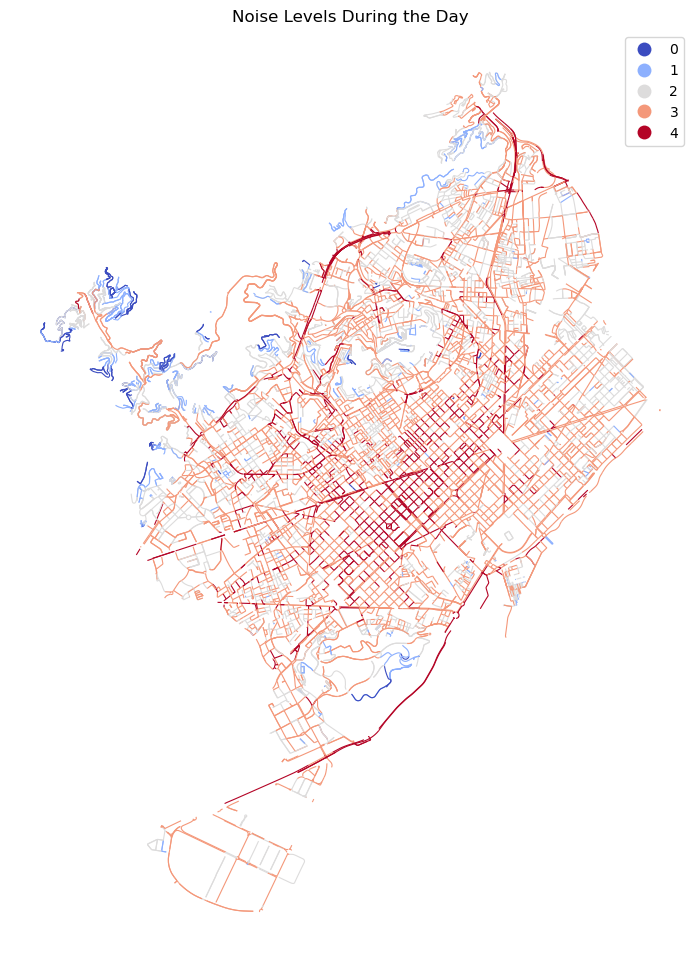

In [13]:
noise_roads['noise_day'] = noise_roads["noise_day"].astype("category")
ax = noise_roads.plot(cmap="coolwarm", column='noise_day',categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Day')
ax.set_axis_off()

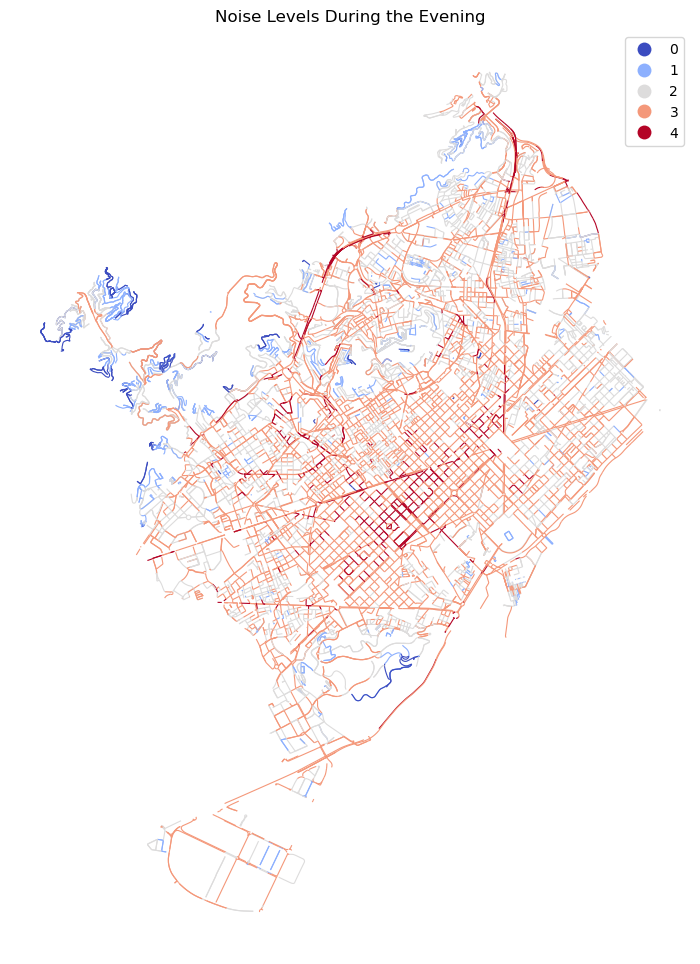

In [14]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_evening', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Evening')
ax.set_axis_off()

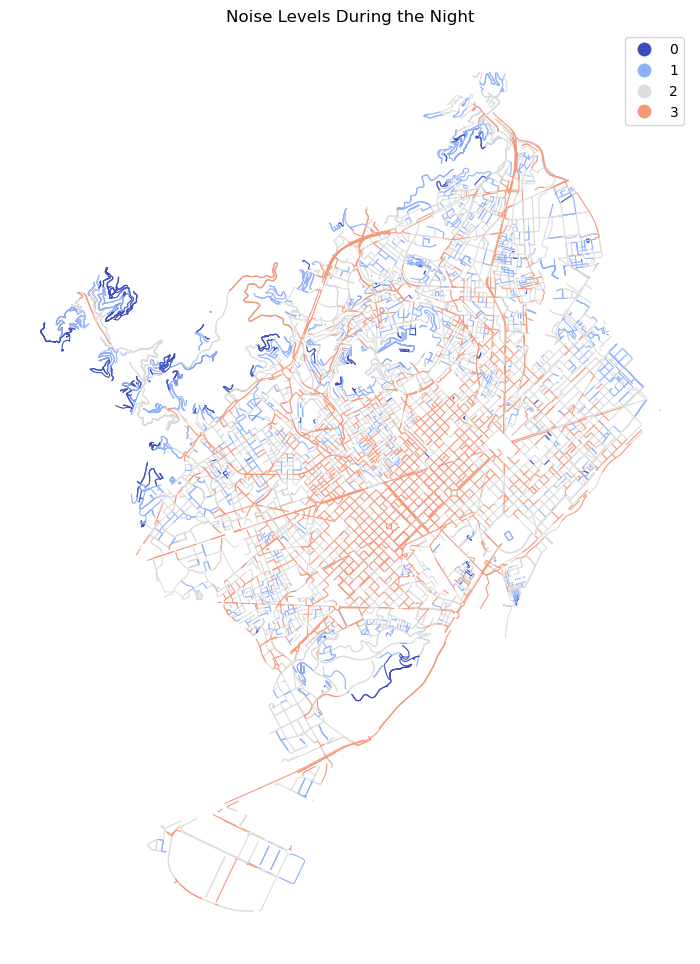

In [15]:
ax = noise_roads.plot(cmap="coolwarm", column='noise_night', categorical=True, linewidth=0.8, legend=True, figsize=(12, 12), vmin=0, vmax=4)
ax.set_title('Noise Levels During the Night')
ax.set_axis_off()

## Convert category to numerical feature

In [16]:
noise_roads['road_category'] = noise_roads['highway']
noise_roads['road_category'].value_counts()

road_category
residential      8080
tertiary         2588
living_street    2121
secondary        1439
primary           512
trunk              69
Name: count, dtype: int64

In [17]:
category_map = {
    'trunk': 1,
    'primary': 2,
    'secondary': 3,
    'tertiary': 4,
    'residential': 5,
    'living_street': 6
}

noise_roads['category_code'] = noise_roads['highway'].map(category_map)
noise_roads.head()

osmid      highway lanes  \
u           v           key                                              
13859746870 13859746860 0                1518596100  residential     1   
13798851565 8465472214  0                 757887873  residential   NaN   
4538123419  13734642240 0                 959788822    secondary     3   
13845167536 847716886   0    [1449373108, 71213823]  residential   NaN   
                        0    [1449373108, 71213823]  residential   NaN   

                            maxspeed                    name  oneway reversed  \
u           v           key                                                     
13859746870 13859746860 0         30                     NaN    True    False   
13798851565 8465472214  0        NaN    Carrer de les Agudes   False     True   
4538123419  13734642240 0         50  Avinguda del Paral·lel    True    False   
13845167536 847716886   0         30  Carrer d'Albert Llanas    True    False   
                        0         30  Carrer d'Albert Llanas    True    False   

                                 length  \
u           v           key               
13859746870 13859746860 0     18.762307   
13798851565 8465472214  0    280.238316   
4538123419  13734642240 0     23.689922   
13845167536 847716886   0    401.507724   
                        0    401.507724   

                                                                      geometry  \
u           v           key                                                      
13859746870 13859746860 0    LINESTRING (428782.407 4586886.973, 428780.56 ...   
13798851565 8465472214  0    LINESTRING (431222.056 4590315.21, 431244.142 ...   
4538123419  13734642240 0    LINESTRING (430214.313 4580727.014, 430204.33 ...   
13845167536 847716886   0    LINESTRING (429520.922 4585357.367, 429528.093...   
                        0    LINESTRING (429520.922 4585357.367, 429528.093...   

                                 access  ...     PATIS_E geometry_type  \
u           v           key              ...                             
13859746870 13859746860 0           NaN  ...  < 40 dB(A)          Line   
13798851565 8465472214  0    designated  ...  < 40 dB(A)          Line   
4538123419  13734642240 0           yes  ...  < 40 dB(A)          Line   
13845167536 847716886   0           NaN  ...  < 40 dB(A)          Line   
                        0           NaN  ...  < 40 dB(A)          Line   

                                start       end distance noise_day  \
u           v           key                                          
13859746870 13859746860 0    428785.0  428671.0      0.0         2   
13798851565 8465472214  0    431316.0  431303.0      0.0         2   
4538123419  13734642240 0    430214.0  430120.0      0.0         3   
13845167536 847716886   0    429757.0  429698.0      0.0         2   
                        0    429619.0  429661.0      0.0         2   

                            noise_evening noise_night  road_category  \
u           v           key                                            
13859746870 13859746860 0               2           2    residential   
13798851565 8465472214  0               2           1    residential   
4538123419  13734642240 0               3           3      secondary   
13845167536 847716886   0               2           1    residential   
                        0               2           2    residential   

                             category_code  
u           v           key                 
13859746870 13859746860 0                5  
13798851565 8465472214  0                5  
4538123419  13734642240 0                3  
13845167536 847716886   0                5  
                        0                5  

[5 rows x 55 columns]

## Calculate distance to the closest road of each category

In [18]:
# Ensure unique index and keep a stable row id for repeated nearest joins
noise_roads = noise_roads.reset_index(drop=True).copy()
noise_roads['road_idx'] = noise_roads.index

# Drop join helper columns if they exist to avoid conflicts in repeated runs
join_helper_cols = ['index_right'] + [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads = noise_roads.drop(columns=[col for col in join_helper_cols if col in noise_roads.columns], errors='ignore')

road_categories = ['trunk', 'primary', 'secondary', 'tertiary', 'residential', 'living_street']

for category in road_categories:
    category_roads = noise_roads[noise_roads['highway'] == category][['geometry']].copy()
    distance_col = f'dist_to_{category}'

    if category_roads.empty:
        noise_roads[distance_col] = pd.NA
        continue

    nearest_category = noise_roads[['road_idx', 'geometry']].sjoin_nearest(
        category_roads,
        how='left',
        distance_col=distance_col
    )
    min_distances = nearest_category.groupby('road_idx')[distance_col].min()
    noise_roads[distance_col] = noise_roads['road_idx'].map(min_distances)

noise_roads = noise_roads.drop(columns=['road_idx']).drop_duplicates(subset='segment_id', keep='first')
noise_roads.head()


,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,1518596100,residential,1,30,NaN,True,False,18.762307,"LINESTRING (428782.407 4586886.973, 428780.56 ...",NaN,...,2,2,residential,5,213.093233,512.208689,1110.052349,188.355179,0.0,385.612798
1,757887873,residential,NaN,NaN,Carrer de les Agudes,False,True,280.238316,"LINESTRING (431222.056 4590315.21, 431244.142 ...",designated,...,2,1,residential,5,549.529452,1655.791584,2110.530434,351.777378,0.0,117.669324
2,959788822,secondary,3,50,Avinguda del Paral·lel,True,False,23.689922,"LINESTRING (430214.313 4580727.014, 430204.33 ...",yes,...,3,3,secondary,3,904.118521,947.154817,0.000000,167.026629,0.0,19.810222
3,"[1449373108, 71213823]",residential,NaN,30,Carrer d'Albert Llanas,True,False,401.507724,"LINESTRING (429520.922 4585357.367, 429528.093...",NaN,...,2,1,residential,5,1877.603526,419.287598,661.587375,10.597441,0.0,41.365655
6,"[264981588, 1449373109]",residential,NaN,30,Carrer d'Albert Llanas,True,False,20.057745,"LINESTRING (429520.922 4585357.367, 429521.637...",NaN,...,2,2,residential,5,1872.177506,614.353897,967.746460,0.000000,0.0,49.109562


In [19]:
# Summarize distance-to-category features
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]
noise_roads[distance_cols].describe()

,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
count,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000,12854.000000
mean,1574.207505,770.632554,358.102541,136.237647,13.626370,171.068801
std,866.870964,780.270700,396.706623,159.198927,41.096636,402.823435
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,878.944655,228.139616,63.860678,0.000000,0.000000,0.000000
50%,1536.029196,545.761596,242.976196,96.752395,0.000000,77.404962
75%,2280.943228,1072.129632,515.907442,209.046896,0.000000,176.287097
max,3795.636971,4669.844695,2567.140076,1060.917082,725.111180,3918.367634


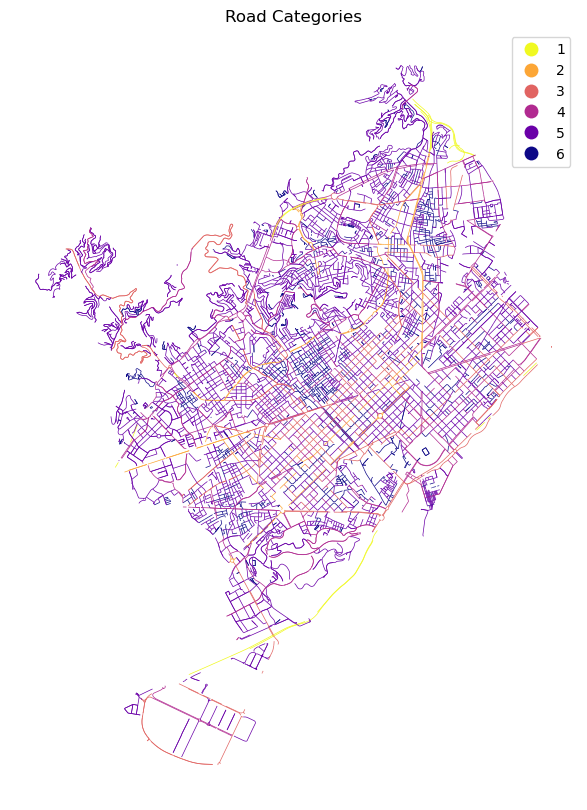

In [32]:
# Plot Road Categories
ax = noise_roads.plot(column='category_code', cmap='plasma_r', categorical=True,linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Road Categories')
ax.set_axis_off()

In [21]:
noise_roads.head()

,osmid,highway,lanes,maxspeed,name,oneway,reversed,length,geometry,access,...,noise_evening,noise_night,road_category,category_code,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,1518596100,residential,1,30,NaN,True,False,18.762307,"LINESTRING (428782.407 4586886.973, 428780.56 ...",NaN,...,2,2,residential,5,213.093233,512.208689,1110.052349,188.355179,0.0,385.612798
1,757887873,residential,NaN,NaN,Carrer de les Agudes,False,True,280.238316,"LINESTRING (431222.056 4590315.21, 431244.142 ...",designated,...,2,1,residential,5,549.529452,1655.791584,2110.530434,351.777378,0.0,117.669324
2,959788822,secondary,3,50,Avinguda del Paral·lel,True,False,23.689922,"LINESTRING (430214.313 4580727.014, 430204.33 ...",yes,...,3,3,secondary,3,904.118521,947.154817,0.000000,167.026629,0.0,19.810222
3,"[1449373108, 71213823]",residential,NaN,30,Carrer d'Albert Llanas,True,False,401.507724,"LINESTRING (429520.922 4585357.367, 429528.093...",NaN,...,2,1,residential,5,1877.603526,419.287598,661.587375,10.597441,0.0,41.365655
6,"[264981588, 1449373109]",residential,NaN,30,Carrer d'Albert Llanas,True,False,20.057745,"LINESTRING (429520.922 4585357.367, 429521.637...",NaN,...,2,2,residential,5,1872.177506,614.353897,967.746460,0.000000,0.0,49.109562


## Create data frame

In [22]:
distance_cols = [col for col in noise_roads.columns if col.startswith('dist_to_')]

dataset = pd.DataFrame({
    "road_id": noise_roads['segment_id'],
    "noise_day": noise_roads['noise_day'],
    "noise_evening": noise_roads['noise_evening'],
    "noise_night": noise_roads['noise_night'],
    "road_category": noise_roads['category_code'],
    **{col: noise_roads[col] for col in distance_cols},
}).fillna(0)

dataset = dataset.drop_duplicates(subset='road_id', keep='first')
dataset.head()


,road_id,noise_day,noise_evening,noise_night,road_category,dist_to_trunk,dist_to_primary,dist_to_secondary,dist_to_tertiary,dist_to_residential,dist_to_living_street
0,13859746870_13859746860_0,2,2,2,5,213.093233,512.208689,1110.052349,188.355179,0.0,385.612798
1,13798851565_8465472214_0,2,2,1,5,549.529452,1655.791584,2110.530434,351.777378,0.0,117.669324
2,4538123419_13734642240_0,3,3,3,3,904.118521,947.154817,0.000000,167.026629,0.0,19.810222
3,13845167536_847716886_0,2,2,1,5,1877.603526,419.287598,661.587375,10.597441,0.0,41.365655
6,13845167536_253790691_0,2,2,2,5,1872.177506,614.353897,967.746460,0.000000,0.0,49.109562


## Export dataset to CSV

In [23]:
import os
output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_roads_noise_class.csv"), index=False)
print("Exported roads_noise_class.csv")

Exported roads_noise_class.csv
